In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
PLT_COL = 2
PLT_ROW = 5
PLT_WIDTH = 1
PLT_HEIGHT = 1

In [21]:
img_noisy = cv2.imread('input/test_image_lena_noisy.png', cv2.IMREAD_GRAYSCALE)

if img_noisy is None:
    print('Image not found! please check your file')

plt.figure(figsize=(PLT_WIDTH, PLT_HEIGHT))

<Figure size 100x100 with 0 Axes>

<Figure size 100x100 with 0 Axes>

## Noisy Image

Text(0, 0.5, 'Frequency')

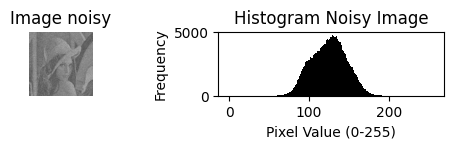

In [22]:
hist_noisy = np.zeros(256, dtype=int)

tinggi, lebar = img_noisy.shape

for i in range(tinggi):
    for j in range(lebar):
        pixel_value = img_noisy[i, j]
        hist_noisy[pixel_value] += 1

plt.subplot(PLT_ROW, PLT_COL, 1)
plt.imshow(img_noisy, cmap='gray', vmin=0, vmax=255)
plt.title('Image noisy')
plt.axis('off')

plt.subplot(PLT_ROW, PLT_COL, 2)
plt.bar(range(256), hist_noisy, color='black', width=1)
plt.title('Histogram Noisy Image')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')

## Median Filter (Denoise 1)
menghilangkan salt & pepper noise

Text(0, 0.5, 'Frekuensi')

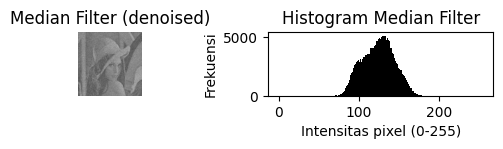

In [23]:
hist_median = np.zeros(256, dtype=int)
kernel_size = 3

offset = kernel_size // 2
tinggi, lebar = img_noisy.shape
result_median = np.zeros((tinggi, lebar), dtype=np.uint8)

padded_img = np.pad(img_noisy, offset, mode='constant', constant_values=0)

for i in range(tinggi):
    for j in range(lebar):
        window = padded_img[i : i + kernel_size, j : j + kernel_size]

        window_flat = window.flatten()
        window_sorted = np.sort(window_flat)
        median_value = window_sorted[len(window_sorted) // 2]

        result_median[i, j] = median_value

        hist_median[result_median[i, j]] += 1

img_median = result_median

plt.subplot(PLT_ROW, PLT_COL, 1)
plt.imshow(img_median, cmap='gray', vmin=0, vmax=255)
plt.title("Median Filter (denoised)")
plt.axis('off')

# histogram mean denoise
plt.subplot(PLT_ROW, PLT_COL, 2)
plt.bar(range(256), hist_median, color='black', width=1)
plt.title('Histogram Median Filter')
plt.xlabel('Intensitas pixel (0-255)')
plt.ylabel('Frekuensi')

## Mean Filter (Denoise 2)
menghaluskan gaussian noise

Text(0, 0.5, 'Frekuensi')

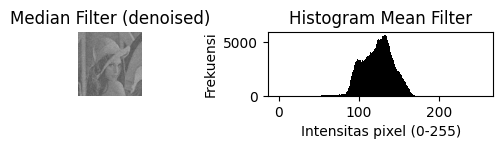

In [24]:
tinggi, lebar = img_median.shape
result_mean = np.zeros((tinggi, lebar), dtype=np.uint8)
hist_mean = np.zeros(256, dtype=int)

kernel = np.ones((5, 5)) / 25.0

offset = kernel.shape[0] // 2
padded_img = np.pad(img_median, offset, mode='constant', constant_values=0)

for i in range(tinggi):
    for j in range(lebar):
        window = padded_img[i : i + kernel.shape[0], j : j + kernel.shape[1]]

        value = np.sum(window * kernel)

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        result_mean[i, j] = value
        hist_mean[result_mean[i, j]] += 1

img_mean = result_mean

plt.subplot(PLT_ROW, PLT_COL, 1)
plt.imshow(img_median, cmap='gray', vmin=0, vmax=255)
plt.title("Median Filter (denoised)")
plt.axis('off')

plt.subplot(PLT_ROW, PLT_COL, 2)
plt.bar(range(256), hist_mean, color='black', width=1)
plt.title('Histogram Mean Filter')
plt.xlabel('Intensitas pixel (0-255)')
plt.ylabel('Frekuensi')

## Sharpen Image

mempertajam tepi

Text(0, 0.5, 'Frekuensi')

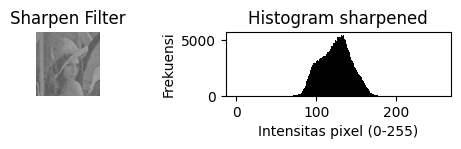

In [25]:
tinggi, lebar = img_mean.shape
result_sharpen = np.zeros((tinggi, lebar), dtype=np.uint8)
hist_sharpen = np.zeros(256, dtype=int)

kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

offset = kernel.shape[0] // 2
padded_img = np.pad(img_mean, offset, mode='constant', constant_values=0)

for i in range(tinggi):
    for j in range(lebar):
        window = padded_img[i : i + kernel.shape[0], j : j + kernel.shape[1]]

        value = np.sum(window * kernel)

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        result_sharpen[i, j] = value
        hist_sharpen[result_sharpen[i, j]] += 1

img_sharpen = result_sharpen
plt.subplot(PLT_ROW, PLT_COL, 1)
plt.imshow(img_sharpen, cmap='gray', vmin=0, vmax=255)
plt.title("Sharpen Filter")
plt.axis('off')

plt.subplot(PLT_ROW, PLT_COL, 2)
plt.bar(range(256), hist_sharpen, color='black', width=1)
plt.title('Histogram sharpened')
plt.xlabel('Intensitas pixel (0-255)')
plt.ylabel('Frekuensi')

## Histogram Equalization
menormalisasi untuk meratakan distribusi pixel (mengatasi low contrast)

Text(0, 0.5, 'Frekuensi')

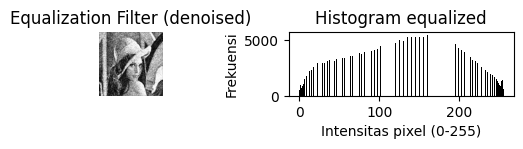

In [26]:
tinggi, lebar = img_sharpen.shape
result_equalization = np.zeros((tinggi, lebar), dtype=np.uint8)
total_pixels = tinggi * lebar
hist_equalization = np.zeros(256, dtype=int)

cdf = np.zeros(256, dtype=int)
cdf[0] = hist_sharpen[0]
for i in range(1, 256):
    cdf[i] = cdf[i - 1] + hist_sharpen[i]

# Cari nilai CDF terkecil & bukan 0
cdf_min = 0
for val in cdf:
    if val > 0:
        cdf_min = val
        break

# Tabel mapping -> rumus normalisasi CDF
mapping = np.zeros(256, dtype=np.uint8)
for i in range(256):
    if cdf[i] > 0:
        nilai_baru = round(((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * 255)
        mapping[i] = nilai_baru

for i in range(tinggi):
    for j in range(lebar):
        nilai_lama = img_sharpen[i, j]
        result_equalization[i, j] = mapping[nilai_lama]

        hist_equalization[result_equalization[i, j]] += 1

img_equalization = result_equalization
plt.subplot(PLT_ROW, PLT_COL, 1)
plt.imshow(img_equalization, cmap='gray', vmin=0, vmax=255)
plt.title("Equalization Filter (denoised)")
plt.axis('off')

plt.subplot(PLT_ROW, PLT_COL, 2)
plt.bar(range(256), hist_equalization, color='black', width=1)
plt.title('Histogram equalized')
plt.xlabel('Intensitas pixel (0-255)')
plt.ylabel('Frekuensi')